In [1]:
!wget https://raw.githubusercontent.com/afrisenti-semeval/afrisent-semeval-2023/main/data/swa/test.tsv -O swa_test.tsv

--2026-04-27 09:53:34--  https://raw.githubusercontent.com/afrisenti-semeval/afrisent-semeval-2023/main/data/swa/test.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 90792 (89K) [text/plain]
Saving to: ‘swa_test.tsv’

swa_test.tsv        100%[===================>]  88.66K  --.-KB/s    in 0.008s  

2026-04-27 09:53:35 (10.7 MB/s) - ‘swa_test.tsv’ saved [90792/90792]



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from datasets import load_dataset
dataset = load_dataset(
    "csv",
    data_files="swa_test.tsv",
    delimiter="\t",
    split='train'
)

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
dataset[0]

{'tweet': '   Ulitaka kujua siasa hzi za democrazy nawaomba musome kitabu kinachoitwa The Prince by Machiavelli Ndio',
 'label': 'positive'}

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

In [122]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [123]:
import torch.nn.functional as F

def build_anchor_ids(label_words, tokenizer):
    anchor_ids = {}

    for label, words in label_words.items():
        word_ids = []

        for w in words:
            token_ids = tokenizer.encode(w, add_special_tokens=False)

            if len(token_ids) > 0:
                word_ids.append(token_ids)

        anchor_ids[label] = word_ids

    return anchor_ids

In [124]:
def build_prompt(text, tokenizer):
    return (
        f"Tweet: {text}. "
        f"This tweet is written in Swahili. "
        f"The emotion of this tweet is {tokenizer.mask_token}."
    )

In [125]:
from collections import Counter
import re

def tokenize_simple(text):
    return re.findall(r"\w+", text.lower())

def build_candidate_vocab(dataset, label_col="label", text_col="tweet", top_k=200):
    label_tokens = {}

    for sample in dataset:
        label = sample[label_col]
        tokens = tokenize_simple(sample[text_col])

        label_tokens.setdefault(label, []).extend(tokens)

    label_vocab = {}
    for label, tokens in label_tokens.items():
        counter = Counter(tokens)

        filtered = [
            w for w, c in counter.most_common(2000)
            if len(w) > 2 and c > 2
        ][:top_k]

        label_vocab[label] = filtered

    return label_vocab

In [126]:
EN_ANCHORS = {
    "positive": ["good", "great", "happy", "love", "excellent", "nice", "positive"],
    "neutral": ["okay", "normal", "fine", "average", "standard", "neutral"],
    "negative": ["bad", "sad", "angry", "hate", "terrible", "worst", "negative"]
}

In [127]:
def build_learned_label_words(dataset):
    sw_vocab = build_candidate_vocab(dataset)

    merged = {}

    for label in sw_vocab:
        merged[label] = list(set(
            sw_vocab[label] + EN_ANCHORS[label]
        ))

    return merged

In [128]:
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import torch.nn.functional as F

def evaluate(
    model,
    dataset,
    tokenizer,
    anchor_ids,
    device,
    temperature=1.0,
    debug=False
):
    model.eval()

    y_true, y_pred = [], []
    y_conf_dict_list = []

    with torch.no_grad():
        for sample in tqdm(dataset):

            text = sample["tweet"]
            label = sample["label"]

            # ---- forward ----
            prompt = build_prompt(text, tokenizer)
            inputs = tokenizer(prompt, return_tensors="pt").to(device)

            mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1][0]

            outputs = model(**inputs)
            logits = outputs.logits[0, mask_idx]

            # ---- calibration ----
            logits = logits / temperature
            log_probs = F.log_softmax(logits, dim=-1)

            # ---- PLL scoring ----
            scores = {}

            for lab, seqs in anchor_ids.items():
                seq_scores = []

                for seq in seqs:
                    seq_tensor = torch.tensor(seq, device=device)
                    token_log_probs = log_probs[seq_tensor]
                    seq_scores.append(token_log_probs.sum())

                scores[lab] = torch.logsumexp(torch.stack(seq_scores), dim=0).item()

            # ---- prediction ----
            pred = max(scores, key=scores.get)

            # confidence (for reliability diagrams)
            probs = torch.tensor(list(scores.values()))
            probs = torch.softmax(probs, dim=0)
            conf = probs.max().item()

            soft = torch.softmax(torch.tensor(list(scores.values())), dim=0)

            conf_dict = {}
            for i, cls in enumerate(scores.keys()):
                conf_dict[cls] = soft[i].item()

            y_true.append(label)
            y_pred.append(pred)
            y_conf_dict_list.append(conf_dict)

            if debug:
                print("\nTEXT:", text)
                print("SCORES:", scores)
                print("PRED:", pred, "TRUE:", label, "CONF:", conf)

    print("\n=== RESULTS ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

    return y_true, y_pred, y_conf_dict_list

In [129]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_reliability_all_classes(y_true, y_conf_dict, classes, n_bins=10):

    plt.figure(figsize=(6, 6))

    # diagonal reference
    plt.plot([0, 1], [0, 1], "--", color="gray")

    for cls in classes:

        # binary ground truth for this class
        y_true_bin = np.array([1 if t == cls else 0 for t in y_true])

        # confidence for THIS class
        y_conf = np.array(y_conf_dict[cls])

        frac_pos, mean_pred = calibration_curve(
            y_true_bin,
            y_conf,
            n_bins=n_bins,
            strategy="quantile"
        )

        plt.plot(mean_pred, frac_pos, marker="o", label=cls)

    plt.title("Reliability Diagram (All Classes)")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [11]:
def predict_mlm_calibrated(
    text,
    model,
    tokenizer,
    anchor_ids,
    baseline_logits,
    device,
    temperature=1,
    debug=False
):
    prompt = build_prompt(text, tokenizer)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1][0]

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, mask_idx]

    calibrated_logits = logits - baseline_logits
    calibrated_logits = calibrated_logits / temperature

    log_probs = F.log_softmax(calibrated_logits, dim=-1)

    scores = {}

    for label, token_sequences in anchor_ids.items():
        seq_scores = []

        for seq in token_sequences:
            seq_tensor = torch.tensor(seq, device=device)
            token_log_probs = log_probs[seq_tensor]
            seq_scores.append(token_log_probs.sum())

        if len(seq_scores) == 0:
            scores[label] = float("-inf")
        else:
            scores[label] = torch.logsumexp(torch.stack(seq_scores), dim=0).item()

    prediction = max(scores, key=scores.get)

    if debug:
        print(f"\nText: {text}")
        print("Calibrated scores:")
        for k, v in scores.items():
            print(f"  {k}: {v:.4f}")

    return prediction, scores

In [130]:
from datasets import DatasetDict, concatenate_datasets

def balance_dataset(dataset, label_col="label", seed=42):
    labels = set(dataset[label_col])

    subsets = {
        label: dataset.filter(lambda x: x[label_col] == label)
        for label in labels
    }

    min_size = min(len(subset) for subset in subsets.values())

    balanced_subsets = [
        subset.shuffle(seed=seed).select(range(min_size))
        for subset in subsets.values()
    ]

    balanced_dataset = concatenate_datasets(balanced_subsets)

    return balanced_dataset.shuffle(seed=seed)

In [131]:
dataset_balanced = balance_dataset(dataset)

# Eval roberta_en

In [132]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

MODEL_PATH = "/content/drive/MyDrive/nlp_project/models/english_lm_roberta"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForMaskedLM.from_pretrained(MODEL_PATH)
model.eval().to(device)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): 

In [133]:
LABEL_WORDS = build_learned_label_words(dataset_balanced)
anchor_ids = build_anchor_ids(LABEL_WORDS, tokenizer)

In [134]:
y_true, y_pred, y_conf_dict_list = evaluate(
    model=model,
    dataset=dataset_balanced,
    tokenizer=tokenizer,
    anchor_ids=anchor_ids,
    device=device,
    temperature=1,
    debug=False
)

100%|██████████| 240/240 [00:09<00:00, 25.70it/s]


=== RESULTS ===
Accuracy: 0.3416666666666667
Macro F1: 0.19716511916374627


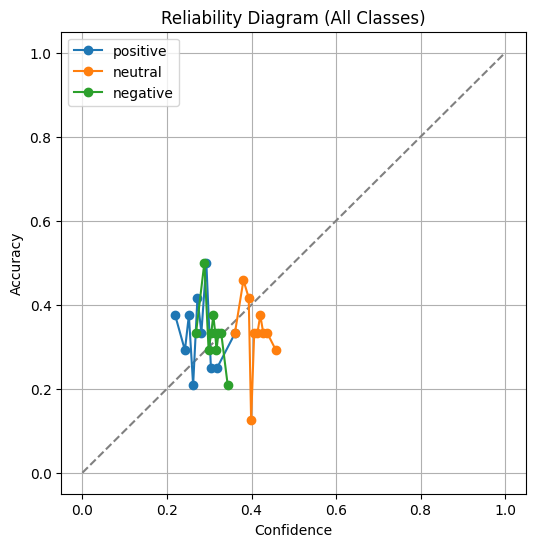

In [135]:
classes = ["positive", "neutral", "negative"]

y_conf_dict = {
    c: [d[c] for d in y_conf_dict_list]
    for c in classes
}
plot_reliability_all_classes(
    y_true,
    y_conf_dict,
    classes=["positive", "neutral", "negative"]
)

# Eval roberta_swahili (continuous pretraining)

In [136]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

MODEL_PATH = "/content/drive/MyDrive/nlp_project/models/roberta_swahili"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForMaskedLM.from_pretrained(MODEL_PATH)
model.eval().to(device)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): 

In [137]:
LABEL_WORDS = build_learned_label_words(dataset_balanced)
anchor_ids = build_anchor_ids(LABEL_WORDS, tokenizer)

In [138]:
y_true, y_pred, y_conf_dict_list = evaluate(
    model=model,
    dataset=dataset_balanced,
    tokenizer=tokenizer,
    anchor_ids=anchor_ids,
    device=device,
    temperature=1,
    debug=False
)

100%|██████████| 240/240 [00:07<00:00, 31.38it/s]


=== RESULTS ===
Accuracy: 0.3333333333333333
Macro F1: 0.16666666666666666


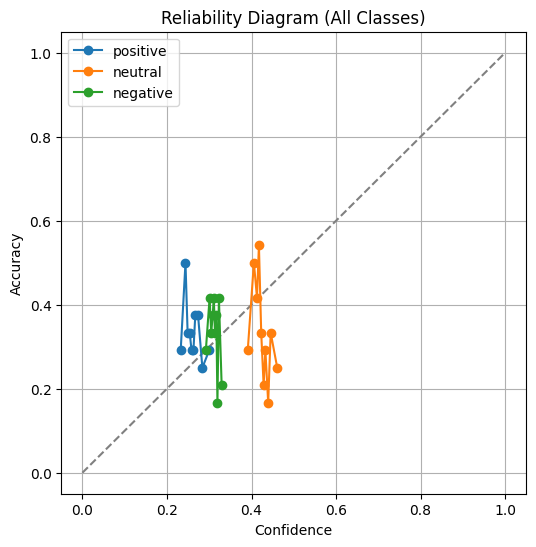

In [139]:
classes = ["positive", "neutral", "negative"]

y_conf_dict = {
    c: [d[c] for d in y_conf_dict_list]
    for c in classes
}
plot_reliability_all_classes(
    y_true,
    y_conf_dict,
    classes=["positive", "neutral", "negative"]
)

# Eval roberta_swahili_retokenize

In [140]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

MODEL_PATH = "/content/drive/MyDrive/nlp_project/models/roberta_swahili_retokenize"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForMaskedLM.from_pretrained(MODEL_PATH)
model.eval().to(device)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(6109, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [141]:
LABEL_WORDS = build_learned_label_words(dataset_balanced)
anchor_ids = build_anchor_ids(LABEL_WORDS, tokenizer)

In [142]:
y_true, y_pred, y_conf_dict_list = evaluate(
    model=model,
    dataset=dataset_balanced,
    tokenizer=tokenizer,
    anchor_ids=anchor_ids,
    device=device,
    temperature=1,
    debug=False
)

100%|██████████| 240/240 [00:07<00:00, 30.43it/s]


=== RESULTS ===
Accuracy: 0.3375
Macro F1: 0.17627608224696892


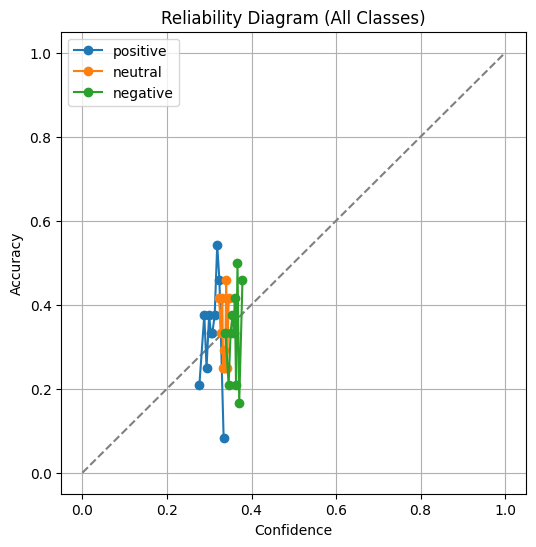

In [143]:
classes = ["positive", "neutral", "negative"]

y_conf_dict = {
    c: [d[c] for d in y_conf_dict_list]
    for c in classes
}
plot_reliability_all_classes(
    y_true,
    y_conf_dict,
    classes=["positive", "neutral", "negative"]
)

# Eval roberta_swahili_adapter

In [144]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
from peft import PeftModel

MODEL_PATH = "/content/drive/MyDrive/nlp_project/models/roberta_swahili_retokenize"
ADAPTER_PATH = "/content/drive/MyDrive/nlp_project/models/roberta_swahili_adapter"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
base_model = AutoModelForMaskedLM.from_pretrained(MODEL_PATH)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval().to(device)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

PeftModelForFeatureExtraction(
  (base_model): LoraModel(
    (model): RobertaForMaskedLM(
      (roberta): RobertaModel(
        (embeddings): RobertaEmbeddings(
          (word_embeddings): Embedding(6109, 768, padding_idx=1)
          (token_type_embeddings): Embedding(1, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (position_embeddings): Embedding(514, 768, padding_idx=1)
        )
        (encoder): RobertaEncoder(
          (layer): ModuleList(
            (0-11): 12 x RobertaLayer(
              (attention): RobertaAttention(
                (self): RobertaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
               

In [145]:
LABEL_WORDS = build_learned_label_words(dataset_balanced)
anchor_ids = build_anchor_ids(LABEL_WORDS, tokenizer)

In [146]:
y_true, y_pred, y_conf_dict_list = evaluate(
    model=model,
    dataset=dataset_balanced,
    tokenizer=tokenizer,
    anchor_ids=anchor_ids,
    device=device,
    temperature=1,
    debug=False
)

100%|██████████| 240/240 [00:08<00:00, 27.38it/s]


=== RESULTS ===
Accuracy: 0.3458333333333333
Macro F1: 0.26279802069275754


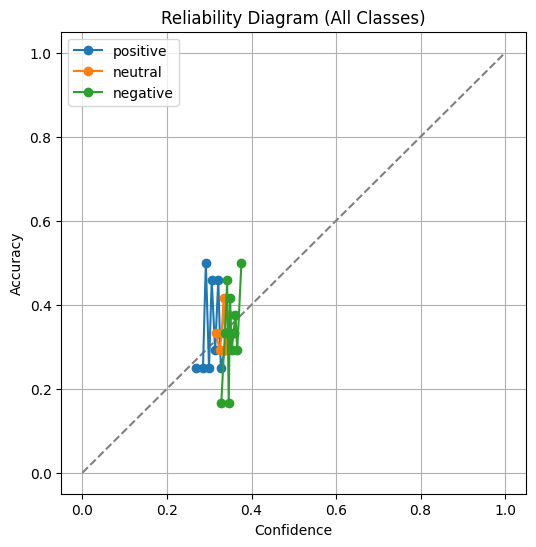

In [147]:
classes = ["positive", "neutral", "negative"]

y_conf_dict = {
    c: [d[c] for d in y_conf_dict_list]
    for c in classes
}
plot_reliability_all_classes(
    y_true,
    y_conf_dict,
    classes=["positive", "neutral", "negative"]
)